In [55]:
import tensorflow as tf

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.cm as cm

from PIL import Image

In [56]:
MODEL_PATH = "/workspaces/plant_disease_detection/artifacts/best_model.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,512,687 (127.84 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,341,792 (85.23 MB)

In [58]:
LAST_CONV_LAYER = "conv2d_2"

In [59]:
DATASET_PATH = "/workspaces/plant_disease_detection/data/raw"

dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

class_names = dataset.class_names

print(class_names)

Found 20638 files belonging to 15 classes.
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [60]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

In [61]:
def preprocess_image(image_path):

    img = Image.open(image_path)

    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    img = np.array(img)

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    return img

In [64]:
IMAGE_PATH = "/workspaces/plant_disease_detection/data/raw/Pepper__bell___healthy/9d74f9ff-7c49-4210-93f8-99b2be15aaad___JR_HL 8366.JPG"

In [65]:
img_array = preprocess_image(IMAGE_PATH)

predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])

predicted_class = class_names[predicted_index]

print("Predicted Disease:")
print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Disease:
Tomato_Late_blight


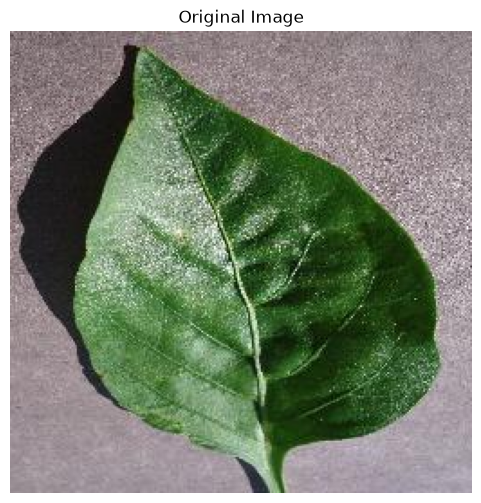

In [66]:
img = Image.open(IMAGE_PATH)

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title("Original Image")

plt.axis("off")

plt.show()

In [67]:
feature_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer(LAST_CONV_LAYER).output
)

In [68]:
feature_maps = feature_extractor.predict(img_array)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
(1, 52, 52, 128)


In [69]:
heatmap = np.mean(feature_maps[0], axis=-1)

print(heatmap.shape)

(52, 52)


In [70]:
heatmap = np.maximum(heatmap, 0)

heatmap = heatmap / np.max(heatmap)

print(heatmap.min())
print(heatmap.max())

0.97644633
1.0


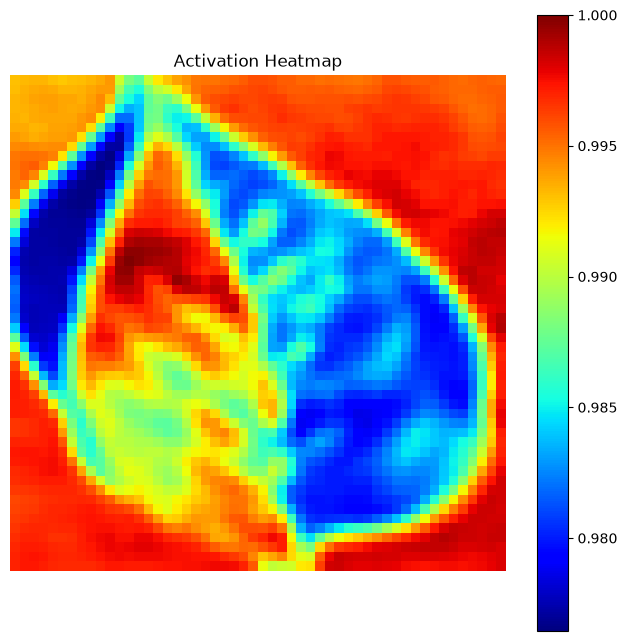

In [71]:
plt.figure(figsize=(8,8))

plt.imshow(heatmap, cmap='jet')

plt.colorbar()

plt.title("Activation Heatmap")

plt.axis("off")

plt.show()

In [74]:
heatmap = np.uint8(255 * heatmap)

jet = plt.get_cmap("jet")

jet_colors = jet(np.arange(256))[:, :3]

jet_heatmap = jet_colors[heatmap]

jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)

jet_heatmap = jet_heatmap.resize((224, 224))

jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

In [75]:
original_img = Image.open(IMAGE_PATH)

original_img = original_img.resize((224,224))

original_img = np.array(original_img)

superimposed_img = (jet_heatmap * 0.4) + original_img

superimposed_img = tf.keras.utils.array_to_img(
    superimposed_img
)

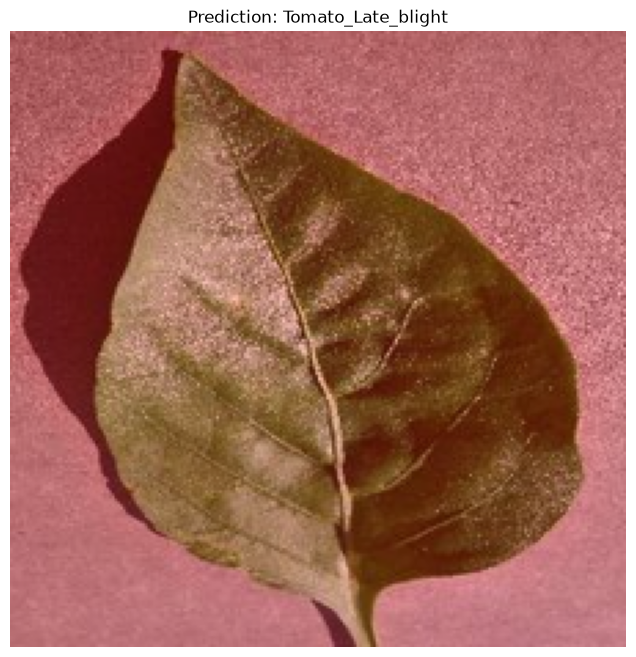

In [76]:
plt.figure(figsize=(8,8))

plt.imshow(superimposed_img)

plt.title(f"Prediction: {predicted_class}")

plt.axis("off")

plt.show()